<a href="https://colab.research.google.com/github/sjkim25/Introduction-to-Artificial-Intelligence/blob/main/week4/Boston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats  # 과학용 계산 라이브러리

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/boston.csv", index_col=0)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


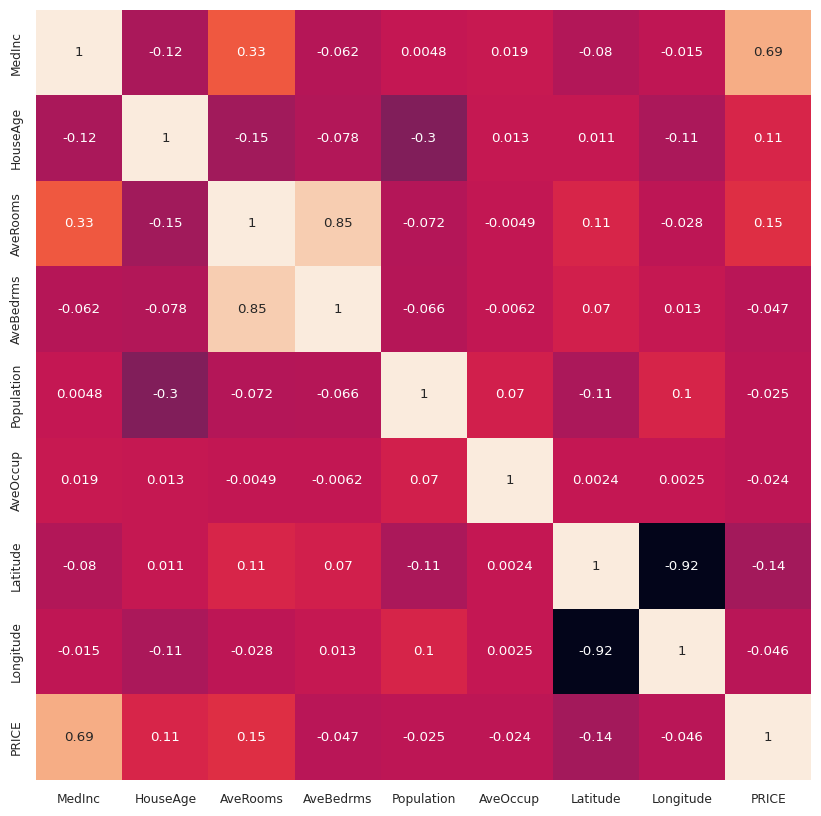

In [36]:
#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음

df_corr=df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

# PRICE와 높은 건  MedInc

In [37]:
# 결측치 측정
print(df.isnull().sum())
print(df.isnull().sum().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64
0


모든 데이터가 연속형이고 평균값. 반올림할 경우 정보 손실이 큼

ex) 1.51만달러와 2.49만 달러가 모두 2가 됨

 -> Classification은 제외하고 Regression만 진행

**// Regression (Feature Selection O)//**

Label: Price

In [47]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/boston.csv", index_col=0)

In [48]:
# Fare과 연관 적은 data drop (0.1 미만)
df.drop(['AveBedrms', 'Population', 'AveOccup', 'Longitude'], axis=1, inplace=True)
df

,MedInc,HouseAge,AveRooms,Latitude,PRICE
0,8.3252,41.0,6.984127,37.88,4.526
1,8.3014,21.0,6.238137,37.86,3.585
2,7.2574,52.0,8.288136,37.85,3.521
3,5.6431,52.0,5.817352,37.85,3.413
4,3.8462,52.0,6.281853,37.85,3.422
...,...,...,...,...,...
20635,1.5603,25.0,5.045455,39.48,0.781
20636,2.5568,18.0,6.114035,39.49,0.771
20637,1.7000,17.0,5.205543,39.43,0.923
20638,1.8672,18.0,5.329513,39.43,0.847


In [49]:
# Target을 제외한 데이터 X에 저장
X_reg = df.drop('PRICE',axis=1)
X_reg.head()

,MedInc,HouseAge,AveRooms,Latitude
0,8.3252,41.0,6.984127,37.88
1,8.3014,21.0,6.238137,37.86
2,7.2574,52.0,8.288136,37.85
3,5.6431,52.0,5.817352,37.85
4,3.8462,52.0,6.281853,37.85


In [50]:
# Target만 y에 저장
y_reg = df['PRICE']
y_reg.value_counts()
y_reg.head()

,PRICE
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [51]:
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, shuffle=True, random_state=12)
print(X_train_r.shape, y_train_r.shape)
print(X_test_r.shape, y_test_r.shape)

(16512, 4) (16512,)
(4128, 4) (4128,)


In [52]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train_r, y_train_r)
ly_preds = model.predict(X_test_r)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test_r))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test_r))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차($):', rmse)

평균제곱근오차 0.6408681554184652
평균제곱근오차 0.6408681554184652
평균제곱근오차 0.6408681554184622
실제 평균 오차($): 0.8005424132539545


In [53]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train_r, y_train_r)

from sklearn.metrics import mean_squared_error

dy_preds = model.predict(X_test_r)
print('평균제곱근오차', mean_squared_error(dy_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차($):', rmse)

평균제곱근오차 0.8685088541037305
실제 평균 오차($): 0.8005424132539545


In [54]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train_r, y_train_r)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test_r)
print('평균제곱근오차', mean_squared_error(ry_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차($):', rmse)

평균제곱근오차 0.45740130235985094
실제 평균 오차($): 0.8005424132539545


**// Regression (Feature Selection X)//**

Label: Price

In [55]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/boston.csv", index_col=0)

In [56]:
# Target을 제외한 데이터 X에 저장
X_reg = df.drop('PRICE',axis=1)
X_reg.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [57]:
# Target만 y에 저장
y_reg = df['PRICE']
y_reg.value_counts()
y_reg.head()

,PRICE
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [58]:
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, shuffle=True, random_state=12)
print(X_train_r.shape, y_train_r.shape)
print(X_test_r.shape, y_test_r.shape)

(16512, 8) (16512,)
(4128, 8) (4128,)


In [59]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train_r, y_train_r)
ly_preds = model.predict(X_test_r)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test_r))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test_r))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차($):', rmse)

평균제곱근오차 0.5269927956248035
평균제곱근오차 0.5269927956248035
평균제곱근오차 0.5269927956248022
실제 평균 오차($): 0.7259426944496401


In [60]:
#Decision Tree
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train_r, y_train_r)

from sklearn.metrics import mean_squared_error

dy_preds = model.predict(X_test_r)
print('평균제곱근오차', mean_squared_error(dy_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차($):', rmse)

평균제곱근오차 0.48088458823132263
실제 평균 오차($): 0.7259426944496401


In [61]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train_r, y_train_r)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test_r)
print('평균제곱근오차', mean_squared_error(ry_preds, y_test_r))

# RMSE (평균제곱근오차) 계산
rmse = np.sqrt(mean_squared_error(y_test_r, ly_preds))
print('실제 평균 오차($):', rmse)

평균제곱근오차 0.2517299905528701
실제 평균 오차($): 0.7259426944496401


Feature Selection을 하지 않은 결과 정확도 변동 (평균제곱근오차)

*   Linear Regression: 0.6408681554184652 -> 0.5269927956248035
*   Decision Tree: 0.8685088541037305 -> 0.7259426944496401
*   Random Forest: 0.45740130235985094 -> 0.2517299905528701